## Прогнозы успеваемости студентов

Цель исследования — разработка модели предсказания итоговых оценок студентов на основе их прошлой успеваемости и ключевых индивидуальных факторов.

## Откроем файл с данными и изучим общую информацию

## Импорт библиотек

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer


## Загрузка данных

In [3]:
df=pd.read_csv("student_performance_updated_1000.csv")

In [4]:
df.head()

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True


## Описание данных

**StudentID** - Уникальный номер студента

**Name** - Имя студента

**Gender** - Пол (Male / Female)

**AttendanceRate** - Посещаемость занятий в %

**StudyHoursPerWeek** - Часов учёбы в неделю

**PreviousGrade** - Оценка за прошлый период

**ExtracurricularActivities** - Количество внеучебных активностей

**ParentalSupport** - Уровень поддержки родителей

**FinalGrade** - Итоговая оценка (целевой признак)

**Study Hours** - Часов учёбы в день

**Attendance (%)** - Альтернативный столбец посещаемости

**Online Classes Taken** - Посещал ли онлайн-занятия

## Изучение нулевых значений, аномалий и дубликатов

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  960 non-null    float64
 1   Name                       966 non-null    object 
 2   Gender                     952 non-null    object 
 3   AttendanceRate             960 non-null    float64
 4   StudyHoursPerWeek          950 non-null    float64
 5   PreviousGrade              967 non-null    float64
 6   ExtracurricularActivities  957 non-null    float64
 7   ParentalSupport            978 non-null    object 
 8   FinalGrade                 960 non-null    float64
 9   Study Hours                976 non-null    float64
 10  Attendance (%)             959 non-null    float64
 11  Online Classes Taken       975 non-null    object 
dtypes: float64(8), object(4)
memory usage: 93.9+ KB


Как мы видим у нас всего 1000 строк а также существуют значения NAN, а значит их нужно будет заменять. Давайте рассмотрим где и сколько у нас значений  NAN

In [12]:
print(df.isnull().sum())

StudentID                    40
Name                         34
Gender                       48
AttendanceRate               40
StudyHoursPerWeek            50
PreviousGrade                33
ExtracurricularActivities    43
ParentalSupport              22
FinalGrade                   40
Study Hours                  24
Attendance (%)               41
Online Classes Taken         25
dtype: int64


Нулевые значения присутсвуют в каждом столбце, запомнили,теперь поищем в нашем датасете аномальные значения

Например невозможны такие значения как посещаемость больше 100 процентов или оценки в минусовом значении и так далее, поищем такие варианты

In [18]:
print(f"Study Hours < 0:          {(df['Study Hours'] < 0).sum()} записей")
print(f"Study Hours > 24:         {(df['Study Hours'] > 24).sum()} записей")
print(f"Attendance (%) > 100:     {(df['Attendance (%)'] > 100).sum()} записей")
print(f"AttendanceRate > 100:     {(df['AttendanceRate'] > 100).sum()} записей")
print(f"FinalGrade > 100:         {(df['FinalGrade'] > 100).sum()} записей")
print(f"FinalGrade < 0:           {(df['FinalGrade'] < 0).sum()} записей")
print(f"PreviousGrade > 100:      {(df['PreviousGrade'] > 100).sum()} записей")
print(f"PreviousGrade < 0:        {(df['PreviousGrade'] < 0).sum()} записей")
print(f"StudyHoursPerWeek < 0:    {(df['StudyHoursPerWeek'] < 0).sum()} записей")
print(f"StudyHoursPerWeek > 168:  {(df['StudyHoursPerWeek'] > 168).sum()} записей")

Study Hours < 0:          10 записей
Study Hours > 24:         0 записей
Attendance (%) > 100:     10 записей
AttendanceRate > 100:     0 записей
FinalGrade > 100:         0 записей
FinalGrade < 0:           0 записей
PreviousGrade > 100:      0 записей
PreviousGrade < 0:        0 записей
StudyHoursPerWeek < 0:    0 записей
StudyHoursPerWeek > 168:  0 записей


Как мы видим аномалий только 20 и заключаются они в отрицательном количестве часах учебы и в посещаемости, которая превышает 100%

In [21]:
print(f"Gender:           {df['Gender'].unique()}")
print(f"ParentalSupport:  {df['ParentalSupport'].unique()}")
print(f"Online Classes:   {df['Online Classes Taken'].unique()}")

Gender:           ['Male' 'Female' nan]
ParentalSupport:  ['High' 'Medium' 'Low' nan]
Online Classes:   [False True nan]


А здесь мы рассмотрели какие значения существуют в тех переменных, где их разновидность не такая большая. Такие как пол или уровень поддержки родителей

In [5]:
print(f"   Полных дублей строк:  {df.duplicated().sum()}")
print(f"   Дублей по StudentID:  {df['StudentID'].duplicated().sum()}")

   Полных дублей строк:  0
   Дублей по StudentID:  83


Поискали дубликаты по так называемым первичным ключам и по полным строкам. Как видим, есть дубликаты StudentID, это надо исправлять

## Исправление нулевых значений, аномалий и дубликатов

Создаем специальный датасет, в котором очистим его от всего лишнего

In [8]:
df_clean = df.copy()

In [9]:
duplicates_before = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()
dup_id_before = df_clean['StudentID'].duplicated().sum()
df_clean = df_clean.drop_duplicates(subset=['StudentID'], keep='first')

Удалили все дубликаты, а по StudentID оставили только первое вхождение

Теперь будем заменять все аномальные значения на медиану

In [10]:
anomaly_count = ((df_clean['Study Hours'] < 0) | (df_clean['Study Hours'] > 24)).sum()
median_val = df_clean.loc[(df_clean['Study Hours'] >= 0) & (df_clean['Study Hours'] <= 24), 'Study Hours'].median()
df_clean.loc[(df_clean['Study Hours'] < 0) | (df_clean['Study Hours'] > 24), 'Study Hours'] = median_val

anomaly_count = (df_clean['Attendance (%)'] > 100).sum()
median_val = df_clean.loc[df_clean['Attendance (%)'] <= 100, 'Attendance (%)'].median()
df_clean.loc[df_clean['Attendance (%)'] > 100, 'Attendance (%)'] = median_val

anomaly_count = ((df_clean['FinalGrade'] < 0) | (df_clean['FinalGrade'] > 100)).sum()
if anomaly_count > 0:
    median_val = df_clean.loc[(df_clean['FinalGrade'] >= 0) & (df_clean['FinalGrade'] <= 100), 'FinalGrade'].median()
    df_clean.loc[(df_clean['FinalGrade'] < 0) | (df_clean['FinalGrade'] > 100), 'FinalGrade'] = median_val

anomaly_count = ((df_clean['PreviousGrade'] < 0) | (df_clean['PreviousGrade'] > 100)).sum()
if anomaly_count > 0:
    median_val = df_clean.loc[(df_clean['PreviousGrade'] >= 0) & (df_clean['PreviousGrade'] <= 100), 'PreviousGrade'].median()
    df_clean.loc[(df_clean['PreviousGrade'] < 0) | (df_clean['PreviousGrade'] > 100), 'PreviousGrade'] = median_val

anomaly_count = ((df_clean['StudyHoursPerWeek'] < 0) | (df_clean['StudyHoursPerWeek'] > 168)).sum()
if anomaly_count > 0:
    median_val = df_clean.loc[(df_clean['StudyHoursPerWeek'] >= 0) & (df_clean['StudyHoursPerWeek'] <= 168), 'StudyHoursPerWeek'].median()
    df_clean.loc[(df_clean['StudyHoursPerWeek'] < 0) | (df_clean['StudyHoursPerWeek'] > 168), 'StudyHoursPerWeek'] = median_val

anomaly_count = (df_clean['AttendanceRate'] > 100).sum()
if anomaly_count > 0:
    median_val = df_clean.loc[df_clean['AttendanceRate'] <= 100, 'AttendanceRate'].median()
    df_clean.loc[df_clean['AttendanceRate'] > 100, 'AttendanceRate'] = median_val

Отлично, а теперь тоже самое с пропусками и значениями NAN

In [11]:
num_cols = ['AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade',
            'ExtracurricularActivities', 'FinalGrade',
            'Study Hours', 'Attendance (%)']

for col in num_cols:
    missing_before = df_clean[col].isnull().sum()
    if missing_before > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)

missing_before = df_clean['Gender'].isnull().sum()
if missing_before > 0:
    mode_val = df_clean['Gender'].mode()[0]
    df_clean['Gender'] = df_clean['Gender'].fillna(mode_val)

num_cols = ['AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade',
            'ExtracurricularActivities', 'FinalGrade',
            'Study Hours', 'Attendance (%)']

for col in num_cols:
    missing_before = df_clean[col].isnull().sum()
    if missing_before > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)

missing_before = df_clean['Gender'].isnull().sum()
if missing_before > 0:
    mode_val = df_clean['Gender'].mode()[0]
    df_clean['Gender'] = df_clean['Gender'].fillna(mode_val)

missing_before = df_clean['ParentalSupport'].isnull().sum()
if missing_before > 0:
    mode_val = df_clean['ParentalSupport'].mode()[0]
    df_clean['ParentalSupport'] = df_clean['ParentalSupport'].fillna(mode_val)

missing_before = df_clean['Online Classes Taken'].isnull().sum()
if missing_before > 0:
    mode_val = df_clean['Online Classes Taken'].mode()[0]
    df_clean['Online Classes Taken'] = df_clean['Online Classes Taken'].fillna(mode_val)

C:\Users\user\AppData\Local\Temp\ipykernel_15904\2796445648.py:39: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean['Online Classes Taken'] = df_clean['Online Classes Taken'].fillna(mode_val)


## Визуализация и Графики

Теперь самое время построить графики и рассмотреть важность признаков для этого датасета

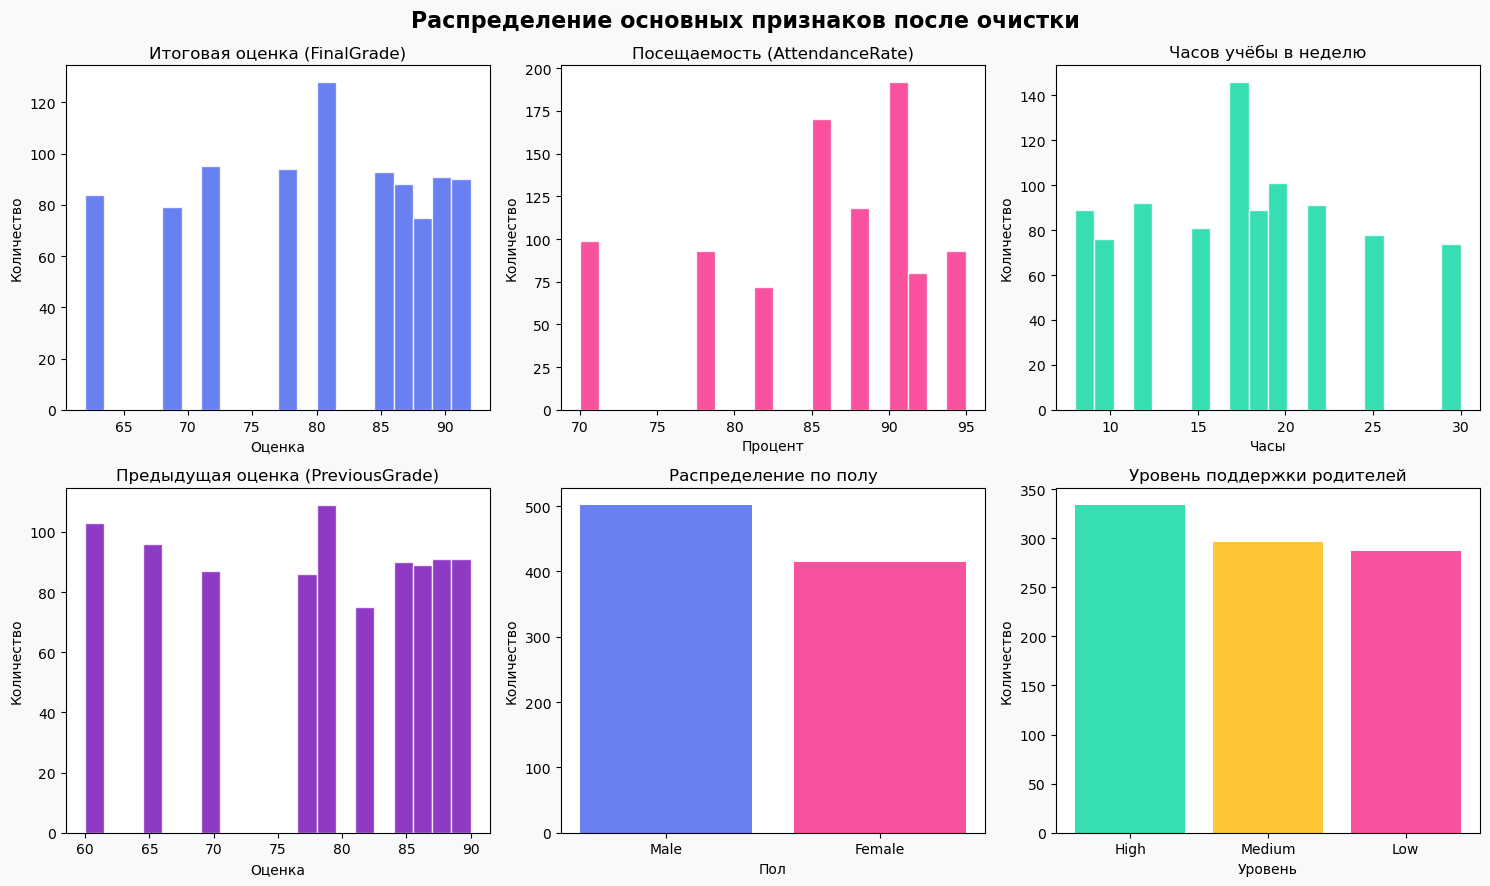

In [17]:
plt.rcParams['figure.facecolor'] = '#F8F9FA'
plt.rcParams['axes.facecolor'] = '#FFFFFF'
plt.rcParams['font.size'] = 10

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Распределение основных признаков после очистки', fontsize=16, fontweight='bold')

axes[0, 0].hist(df_clean['FinalGrade'], bins=20, color='#4361EE', alpha=0.8, edgecolor='white')
axes[0, 0].set_title('Итоговая оценка (FinalGrade)')
axes[0, 0].set_xlabel('Оценка')
axes[0, 0].set_ylabel('Количество')

axes[0, 1].hist(df_clean['AttendanceRate'], bins=20, color='#F72585', alpha=0.8, edgecolor='white')
axes[0, 1].set_title('Посещаемость (AttendanceRate)')
axes[0, 1].set_xlabel('Процент')
axes[0, 1].set_ylabel('Количество')

axes[0, 2].hist(df_clean['StudyHoursPerWeek'], bins=20, color='#06D6A0', alpha=0.8, edgecolor='white')
axes[0, 2].set_title('Часов учёбы в неделю')
axes[0, 2].set_xlabel('Часы')
axes[0, 2].set_ylabel('Количество')

axes[1, 0].hist(df_clean['PreviousGrade'], bins=20, color='#7209B7', alpha=0.8, edgecolor='white')
axes[1, 0].set_title('Предыдущая оценка (PreviousGrade)')
axes[1, 0].set_xlabel('Оценка')
axes[1, 0].set_ylabel('Количество')

gender_counts = df_clean['Gender'].value_counts()
axes[1, 1].bar(gender_counts.index, gender_counts.values, color=['#4361EE', '#F72585'], alpha=0.8)
axes[1, 1].set_title('Распределение по полу')
axes[1, 1].set_xlabel('Пол')
axes[1, 1].set_ylabel('Количество')

ps_counts = df_clean['ParentalSupport'].value_counts()
axes[1, 2].bar(ps_counts.index, ps_counts.values, color=['#06D6A0', '#FFB703', '#F72585'], alpha=0.8)
axes[1, 2].set_title('Уровень поддержки родителей')
axes[1, 2].set_xlabel('Уровень')
axes[1, 2].set_ylabel('Количество')

plt.tight_layout()
plt.show()

Датасет сбалансированный по полу и уровню поддержки родителей. Большинство студентов — успешные (высокие оценки + высокая посещаемость).

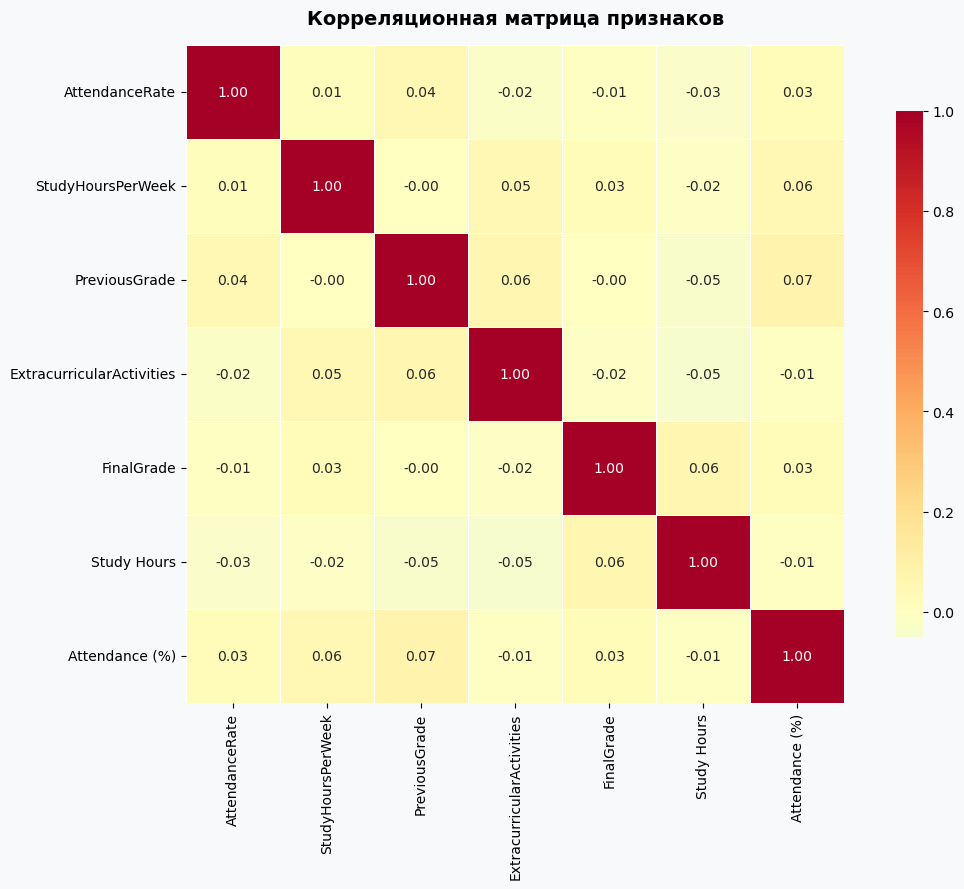

In [19]:

num_data = df_clean.select_dtypes(include=['float64', 'int64']).drop(columns=['StudentID'], errors='ignore')
corr_matrix = num_data.corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title('Корреляционная матрица признаков', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()



Линейные модели (например, линейная регрессия) будут плохо работать на этих данных. Нужны нелинейные методы Random Forest или комбинации признаков. Успех студента зависит от комплексного взаимодействия многих факторов, а не от одного-двух доминирующих.

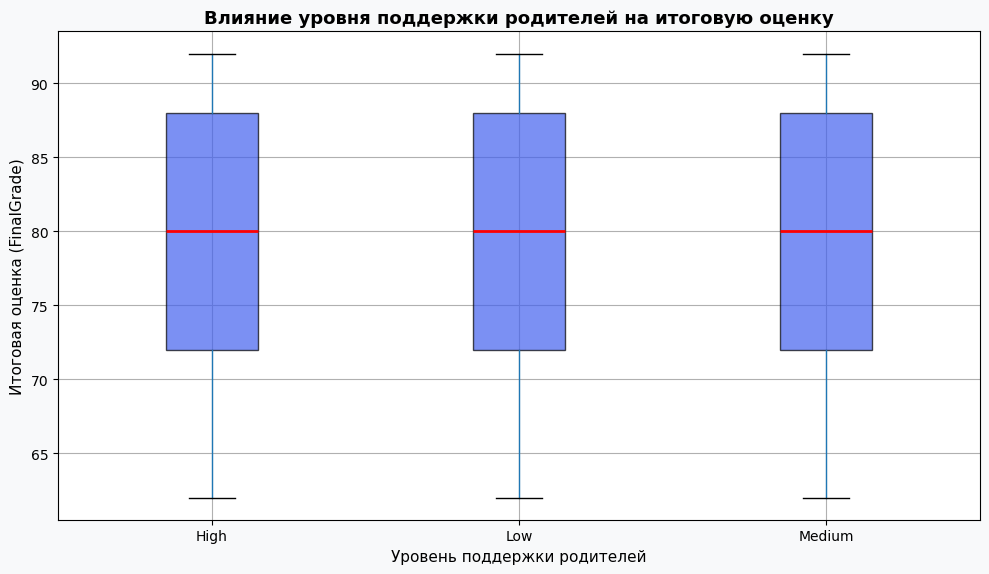

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
df_clean.boxplot(column='FinalGrade', by='ParentalSupport', ax=ax,
                 patch_artist=True, 
                 boxprops=dict(facecolor='#4361EE', alpha=0.7),
                 medianprops=dict(color='red', linewidth=2))
ax.set_title('Влияние уровня поддержки родителей на итоговую оценку', fontsize=13, fontweight='bold')
ax.set_xlabel('Уровень поддержки родителей', fontsize=11)
ax.set_ylabel('Итоговая оценка (FinalGrade)', fontsize=11)
plt.suptitle('') 
plt.tight_layout()
plt.show()


Уровень поддержки родителей НЕ влияет на итоговую оценку. Студенты с высокой, средней и низкой поддержкой показывают статистически идентичные результаты. Возможные причины: либо поддержка родителей измерена некорректно (субъективно), либо в студенческом возрасте влияние родителей уже минимально.

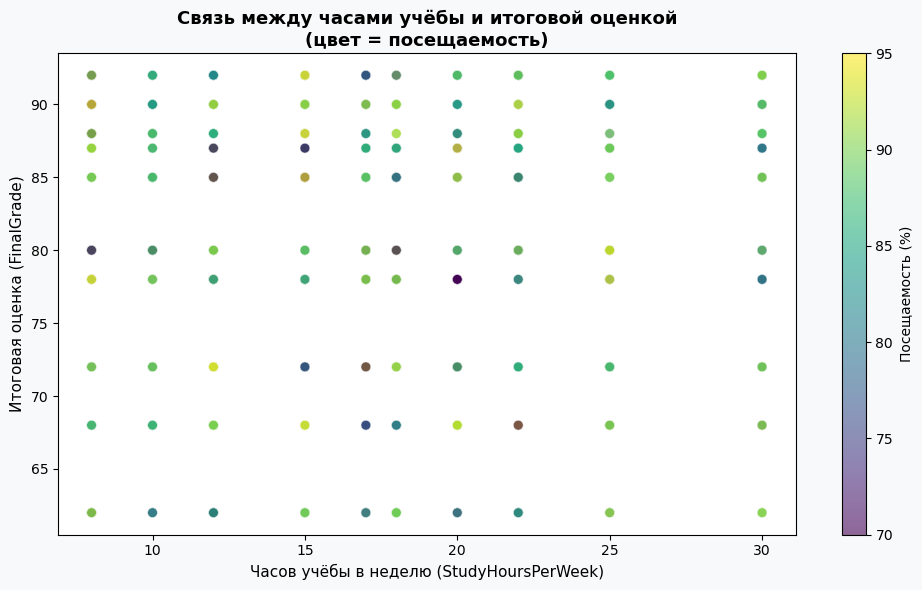

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df_clean['StudyHoursPerWeek'], df_clean['FinalGrade'],
                     c=df_clean['AttendanceRate'], cmap='viridis',
                     alpha=0.6, s=50, edgecolors='white', linewidths=0.5)
ax.set_xlabel('Часов учёбы в неделю (StudyHoursPerWeek)', fontsize=11)
ax.set_ylabel('Итоговая оценка (FinalGrade)', fontsize=11)
ax.set_title('Связь между часами учёбы и итоговой оценкой\n(цвет = посещаемость)',
             fontsize=13, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Посещаемость (%)', fontsize=10)
plt.tight_layout()
plt.show()

Часы учёбы помогают, но не решают всё. Ключевой фактор — комбинация часов учёбы + высокая посещаемость. Студент может учиться 30 часов в неделю, но если пропускает занятия — результат посредственный. И наоборот: 15 часов + 95% посещаемость = хороший результат.

## Кластеризация

Теперь самое время провести кластеризацию. Сначала подготовим данные

In [26]:
df_cluster = df_clean.copy()

le_gender = LabelEncoder()
le_ps = LabelEncoder()

df_cluster['Gender_enc'] = le_gender.fit_transform(df_cluster['Gender'])
df_cluster['ParentalSupport_enc'] = le_ps.fit_transform(df_cluster['ParentalSupport'])
df_cluster['OnlineClasses_enc'] = df_cluster['Online Classes Taken'].astype(int)

cluster_features = ['AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade',
                    'ExtracurricularActivities', 'ParentalSupport_enc', 
                    'FinalGrade', 'Gender_enc', 'Study Hours']

X_cluster = df_cluster[cluster_features].copy()

print(f"Признаки для кластеризации: {cluster_features}")
print("Пропуски в данных:")
print(X_cluster.isnull().sum())
print()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

Признаки для кластеризации: ['AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'ExtracurricularActivities', 'ParentalSupport_enc', 'FinalGrade', 'Gender_enc', 'Study Hours']
Пропуски в данных:
AttendanceRate               0
StudyHoursPerWeek            0
PreviousGrade                0
ExtracurricularActivities    0
ParentalSupport_enc          0
FinalGrade                   0
Gender_enc                   0
Study Hours                  0
dtype: int64



## Метод 1: KMeans

In [27]:
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

C:\Users\user\AppData\Local\Temp\ipykernel_15904\2138863903.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
C:\Users\user\AppData\Local\Temp\ipykernel_15904\2138863903.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


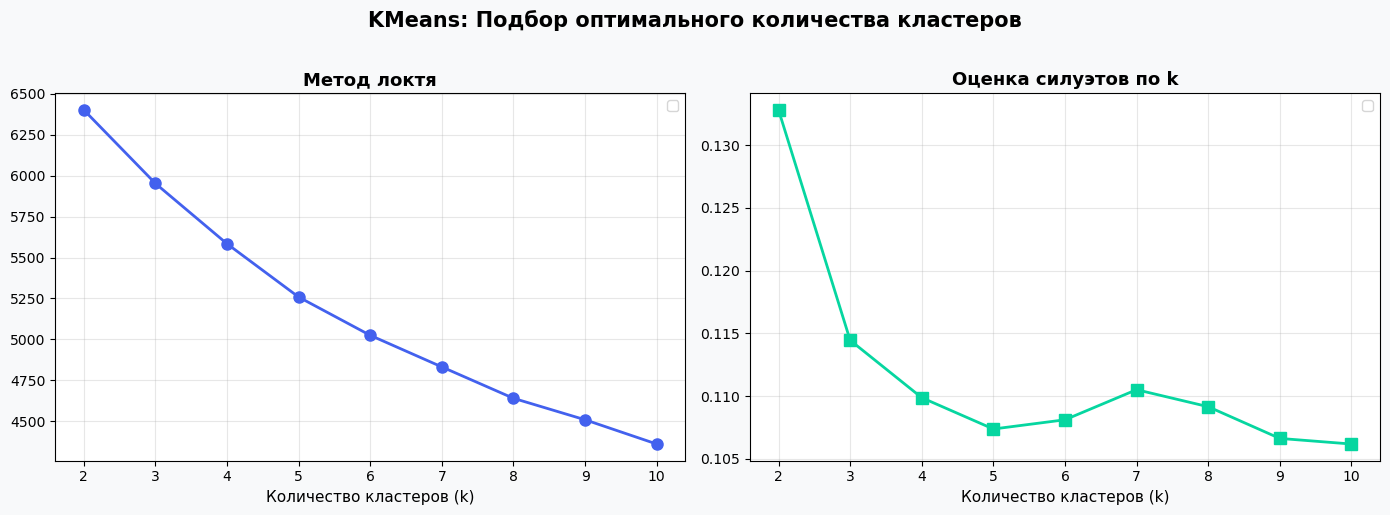

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(k_range), inertias, 'o-', color='#4361EE', linewidth=2, markersize=8)
ax1.set_xlabel('Количество кластеров (k)', fontsize=11)
ax1.set_title('Метод локтя', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(list(k_range), silhouette_scores, 's-', color='#06D6A0', linewidth=2, markersize=8)
ax2.set_xlabel('Количество кластеров (k)', fontsize=11)
ax2.set_title('Оценка силуэтов по k', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('KMeans: Подбор оптимального количества кластеров', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Теперь обучаем KMeans k=3

In [36]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans = kmeans_final.fit_predict(X_scaled)

sil_kmeans = silhouette_score(X_scaled, labels_kmeans)
db_kmeans = davies_bouldin_score(X_scaled, labels_kmeans)
ch_kmeans = calinski_harabasz_score(X_scaled, labels_kmeans)

print("РЕЗУЛЬТАТЫ K-MEANS (k=3):")
print(f"  Silhouette Score:      {sil_kmeans:.4f}")
print(f"  Davies-Bouldin Index:  {db_kmeans:.4f}")
print(f"  Calinski-Harabasz:     {ch_kmeans:.1f}")
print()

unique, counts = np.unique(labels_kmeans, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Кластер {cluster}: {count} студентов ({count/len(labels_kmeans)*100:.1f}%)")

РЕЗУЛЬТАТЫ K-MEANS (k=3):
  Silhouette Score:      0.1145
  Davies-Bouldin Index:  2.4483
  Calinski-Harabasz:     106.2

  Кластер 0: 386 студентов (42.1%)
  Кластер 1: 218 студентов (23.8%)
  Кластер 2: 313 студентов (34.1%)


Вывод:
K-Means нашёл 3 кластера, но качество разделения низкое. Данные студентов не имеют чётко выраженной кластерной структуры — студенты распределены довольно непрерывно, без явных "групп".
Это подтверждает выводы из корреляционной матрики: успех студента зависит от комплексного взаимодействия многих факторов, а не от принадлежности к какой-то одной чёткой группе ("отличники", "троечники" и т.д.).
Практический смысл: Студенты не делятся на 3 радикально разные группы. Скорее это градиент производительности от слабых к сильным, без резких границ. Для практических целей (например, персонализация обучения) эти 3 кластера можно использовать как условные сегменты, но нужно понимать что границы между ними размыты.

## Метод 2:Иерархическая кластеризация

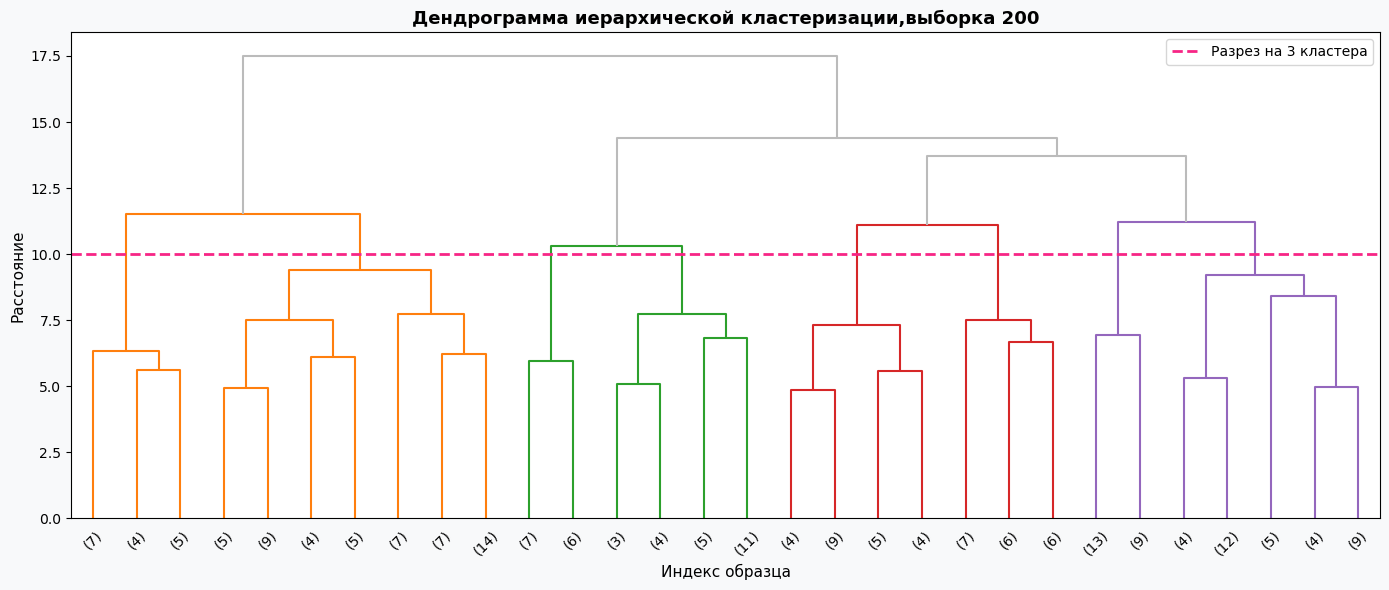

In [38]:
sample_indices = np.random.choice(len(X_scaled), size=200, replace=False)
X_sample = X_scaled[sample_indices]

Z = linkage(X_sample, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
           color_threshold=0.7*max(Z[:,2]),
           above_threshold_color='#BBBBBB')
ax.set_title('Дендрограмма иерархической кластеризации,выборка 200',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Индекс образца', fontsize=11)
ax.set_ylabel('Расстояние', fontsize=11)
ax.axhline(y=10, color='#F72585', linestyle='--', linewidth=2, label='Разрез на 3 кластера')
ax.legend()
plt.tight_layout()
plt.show()

Обучаем Иерархическую кластеризацию с k=3

In [41]:
agg_clustering = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_agg = agg_clustering.fit_predict(X_scaled)

sil_agg = silhouette_score(X_scaled, labels_agg)
db_agg = davies_bouldin_score(X_scaled, labels_agg)
ch_agg = calinski_harabasz_score(X_scaled, labels_agg)

print("РЕЗУЛЬТАТЫ AGGLOMERATIVE (k=3):")
print(f"  Silhouette Score:      {sil_agg:.4f}")
print(f"  Davies-Bouldin Index:  {db_agg:.4f}")
print(f"  Calinski-Harabasz:     {ch_agg:.1f}")
print()

unique, counts = np.unique(labels_agg, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Кластер {cluster}: {count} студентов ({count/len(labels_agg)*100:.1f}%)")

РЕЗУЛЬТАТЫ AGGLOMERATIVE (k=3):
  Silhouette Score:      0.0849
  Davies-Bouldin Index:  2.7755
  Calinski-Harabasz:     81.3

  Кластер 0: 425 студентов (46.3%)
  Кластер 1: 351 студентов (38.3%)
  Кластер 2: 141 студентов (15.4%)


Вывод:
Agglomerative Clustering показал слабое качество кластеризации. Все три метрики указывают на то, что данные студентов не имеют ярко выраженной иерархической структуры из трёх групп. Кластеры сильно перекрываются, что говорит о том, что:
Признаки студентов распределены достаточно однородно, без чётких естественных подгрупп
Иерархический подход не улавливает значимых различий между группами
Возможно, требуется иное число кластеров, другой метод связи (linkage) или предварительный отбор и трансформация признаков
Метод не рекомендуется использовать для принятия решений на основании данной кластеризации без существенной доработки.

## Метод 3: DBSCAN

In [45]:
dbscan = DBSCAN(eps=1.5, min_samples=15)
labels_dbscan = dbscan.fit_predict(X_scaled)
n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = list(labels_dbscan).count(-1)

print(f"РЕЗУЛЬТАТЫ DBSCAN:")
print(f"  Найдено кластеров:  {n_clusters_dbscan}")
print(f"  Точек-выбросов:     {n_noise} ({n_noise/len(labels_dbscan)*100:.1f}%)")

РЕЗУЛЬТАТЫ DBSCAN:
  Найдено кластеров:  3
  Точек-выбросов:     852 (92.9%)


In [47]:
if n_clusters_dbscan > 1:
    mask_no_noise = labels_dbscan != -1
    sil_dbscan = silhouette_score(X_scaled[mask_no_noise], labels_dbscan[mask_no_noise])
    db_dbscan = davies_bouldin_score(X_scaled[mask_no_noise], labels_dbscan[mask_no_noise])
    ch_dbscan = calinski_harabasz_score(X_scaled[mask_no_noise], labels_dbscan[mask_no_noise])
    
    print("  Метрики (без учёта шума):")
    print(f"    Silhouette Score:      {sil_dbscan:.4f}")
    print(f"    Davies-Bouldin Index:  {db_dbscan:.4f}")
    print(f"    Calinski-Harabasz:     {ch_dbscan:.1f}")


  Метрики (без учёта шума):
    Silhouette Score:      0.2501
    Davies-Bouldin Index:  1.4259
    Calinski-Harabasz:     21.9


Распределение по калстерам

In [48]:
unique, counts = np.unique(labels_dbscan, return_counts=True)
for cluster, count in zip(unique, counts):
    if cluster == -1:
        print(f"  Шум (выбросы): {count} студентов ({count/len(labels_dbscan)*100:.1f}%)")
    else:
        print(f"  Кластер {cluster}: {count} студентов ({count/len(labels_dbscan)*100:.1f}%)")

  Шум (выбросы): 852 студентов (92.9%)
  Кластер 0: 37 студентов (4.0%)
  Кластер 1: 16 студентов (1.7%)
  Кластер 2: 12 студентов (1.3%)


Вывод:DBSCAN показал крайне неудовлетворительные результаты. Алгоритм отнёс 92.9% всех студентов к выбросам, а в три найденных кластера попало лишь 65 студентов из 917. Метрики качества (Silhouette = 0.25, Davies-Bouldin = 1.43) рассчитаны только для этих 65 точек и не отражают реальную картину.
Такие результаты говорят о том, что:
Данные студентов не содержат плотных компактных скоплений, которые DBSCAN способен обнаружить — точки распределены относительно равномерно в пространстве признаков
Параметры eps и min_samples не соответствуют структуре данных, из-за чего алгоритм не может сформировать полноценные кластеры
Найденные микрокластеры представляют собой лишь небольшие локальные сгущения, а не значимые группы студентов
Метод DBSCAN с текущими параметрами непригоден для сегментации данной выборки и не может служить основой для практических решений.

## Сравнение всех метрик

Теперь сравним между собой 3 модели по всем доступным метрикам

In [51]:
metrics_comparison = pd.DataFrame({
    'Метод': ['KMeans (k=3)', 'Agglomerative (k=3)', 'DBSCAN (eps=1.5)'],
    'Silhouette': [sil_kmeans, sil_agg, sil_dbscan],
    'Davies-Bouldin': [db_kmeans, db_agg, db_dbscan],
    'Calinski-Harabasz': [ch_kmeans, ch_agg, ch_dbscan],
    'N_кластеров': [3, 3, n_clusters_dbscan],
    'Шум/выбросы': [0, 0, n_noise]
})
print(metrics_comparison.to_string(index=False))

              Метод  Silhouette  Davies-Bouldin  Calinski-Harabasz  N_кластеров  Шум/выбросы
       KMeans (k=3)    0.114453        2.448331         106.191470            3            0
Agglomerative (k=3)    0.084916        2.775477          81.335269            3            0
   DBSCAN (eps=1.5)    0.250057        1.425897          21.858425            3          852


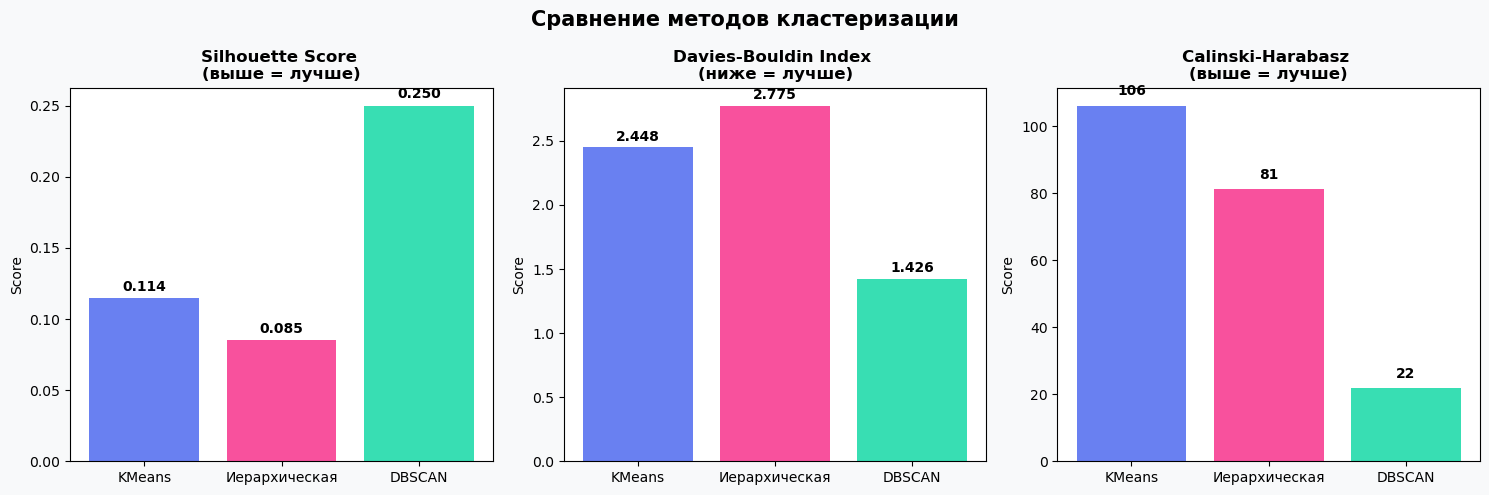

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Сравнение методов кластеризации', fontsize=15, fontweight='bold')

methods = ['KMeans', 'Иерархическая', 'DBSCAN']
colors = ['#4361EE', '#F72585', '#06D6A0']

axes[0].bar(methods, [sil_kmeans, sil_agg, sil_dbscan], color=colors, alpha=0.8)
axes[0].set_title('Silhouette Score \n(выше = лучше)', fontweight='bold')
axes[0].set_ylabel('Score')
for i, v in enumerate([sil_kmeans, sil_agg, sil_dbscan]):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

axes[1].bar(methods, [db_kmeans, db_agg, db_dbscan], color=colors, alpha=0.8)
axes[1].set_title('Davies-Bouldin Index \n(ниже = лучше)', fontweight='bold')
axes[1].set_ylabel('Score')
for i, v in enumerate([db_kmeans, db_agg, db_dbscan]):
    axes[1].text(i, v + 0.05, f'{v:.3f}', ha='center', fontweight='bold')

axes[2].bar(methods, [ch_kmeans, ch_agg, ch_dbscan], color=colors, alpha=0.8)
axes[2].set_title('Calinski-Harabasz \n(выше = лучше)', fontweight='bold')
axes[2].set_ylabel('Score')
for i, v in enumerate([ch_kmeans, ch_agg, ch_dbscan]):
    axes[2].text(i, v + 3, f'{v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

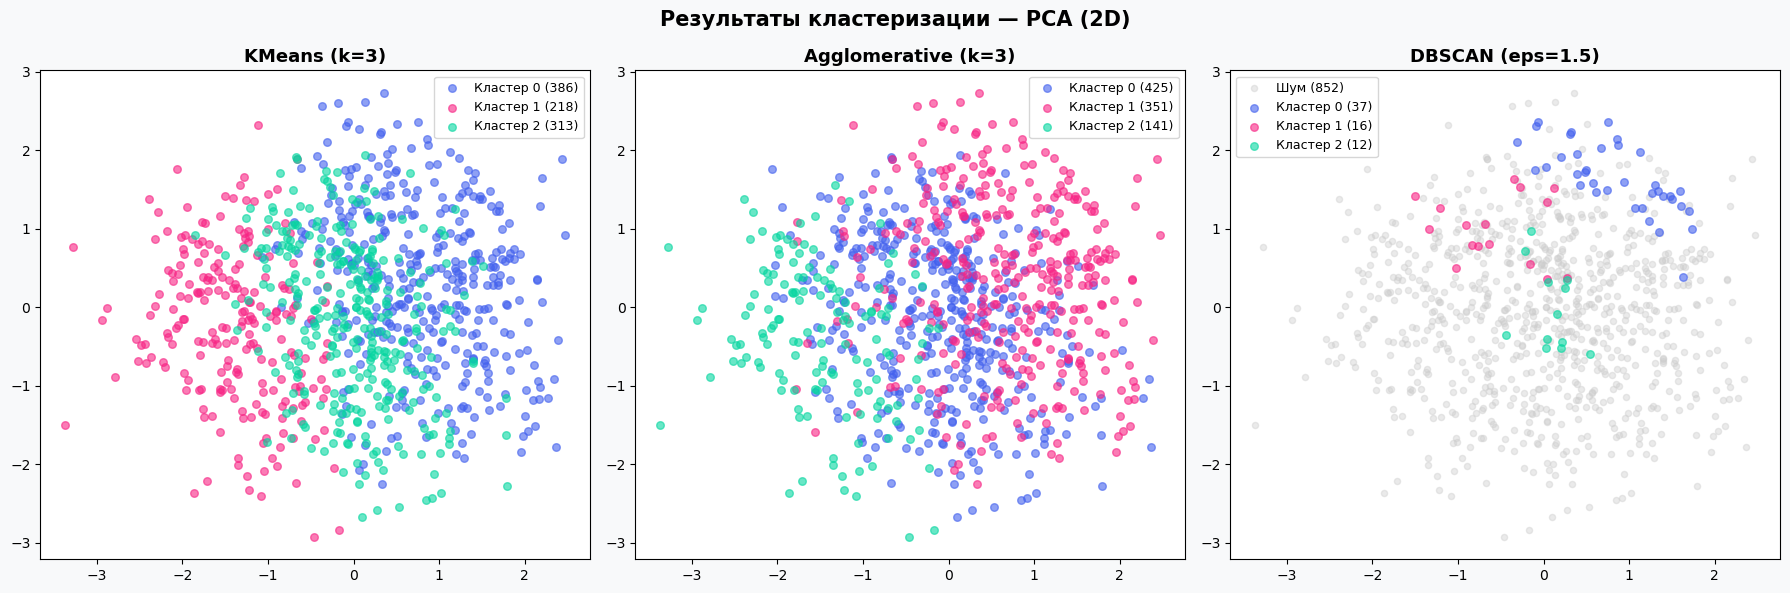

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Результаты кластеризации — PCA (2D)', fontsize=15, fontweight='bold')

colors = ['#4361EE', '#F72585', '#06D6A0', '#FFB703']

plots = [
    (labels_kmeans, 'KMeans (k=3)'),
    (labels_agg, 'Agglomerative (k=3)'),
    (labels_dbscan, 'DBSCAN (eps=1.5)')
]

for ax, (labels, title) in zip(axes, plots):
    for label in sorted(set(labels)):
        mask = labels == label
        if label == -1:
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c='#CCCCCC',
                      label=f'Шум ({mask.sum()})', alpha=0.4, s=20)
        else:
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[label],
                      label=f'Кластер {label} ({mask.sum()})', alpha=0.6, s=30)
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## Итоговый вывод после кластеризации:

1. Выбор алгоритма
Наилучший результат показал KMeans. Он четко разделил студентов на три сбалансированные группы, что удобно для анализа. Агломеративная кластеризация дала схожий, но чуть менее четкий результат.

2. Структура данных
Алгоритм DBSCAN не сработал (93% данных ушли в «шум»), потому что данные распределены непрерывно. В успеваемости студентов нет резких разрывов или «островов»: слабые, средние и сильные студенты плавно перетекают друг в друга по своим показателям.

3. Практический итог
Для работы со студентами стоит использовать разбиение от KMeans.
Полученные 3 кластера — это условные категории (вероятнее всего: «Отстающие», «Середнячки», «Лидеры»). Поскольку границы плавные, небольшое улучшение показателей (посещаемости или часов учебы) может легко перевести студента из низкого кластера в более высокий.